<a href="https://colab.research.google.com/github/jhamidi1/Data201-Spring/blob/main/logistic_regression_assignment_week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np

url = "https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv"
df = pd.read_csv(url)

df.head()

,listing_id,price,size,bedrooms,neighborhood,type
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily


In [30]:
median_price = df["price"].median()

df["high_price"] = (df["price"] > median_price).astype(int)

df.head()

,listing_id,price,size,bedrooms,neighborhood,type,high_price
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse,0
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily,0
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily,0
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily,0
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily,0


## Part A – Logistic Regression for Inference


In [31]:
model = smf.logit(
    "high_price ~ size + bedrooms + C(neighborhood)",
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.684990
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:             high_price   No. Observations:                  524
Model:                          Logit   Df Residuals:                      517
Method:                           MLE   Df Model:                            6
Date:                Fri, 15 May 2026   Pseudo R-squ.:                 0.01177
Time:                        01:07:34   Log-Likelihood:                -358.93
converged:                       True   LL-Null:                       -363.21
Covariance Type:            nonrobust   LLR p-value:                    0.2006
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.3796      0.289      1.311      0.

### Logistic Regression Model Discussion
This notebook uses two logistic regression approaches for different purposes. The statsmodels model is mainly used for inference because it has coefficients, p-values, and odds ratios, which help explain which variables are statistically meaningful. The scikit learn model is used for prediction because it works well with train/test splits, encoded categorical variables, and evaluation metrics like accuracy and ROC–AUC.

## Report Table

In [32]:
results = pd.DataFrame({
    "Coefficient": model.params,
    "Odds Ratio": np.exp(model.params),
    "P-value": model.pvalues
})

results

,Coefficient,Odds Ratio,P-value
Intercept,0.379564,1.461647,0.189716
C(neighborhood)[T.Midtown],-0.306505,0.736015,0.278385
C(neighborhood)[T.Suburb],0.107086,1.113030,0.675176
C(neighborhood)[T.Uptown],0.047048,1.048173,0.864849
C(neighborhood)[T.Waterfront],0.413047,1.511416,0.243135
size,-0.000521,0.999479,0.036679
bedrooms,0.232249,1.261433,0.082236


## Questions:

Which predictors appear statistically significant?
The variable, size is statistically significant, because it's p-value (0.0367) is below 0.05. This shows that house size has a meaningful effect on whether a home is classified as expensive. The variable bedrooms is not statistically significant, and none of the neighborhood categories show statistical significance, showing weaker evidence of their effect on price classification.

Which neighborhood has higher odds of expensive homes? Waterfront has the highest odds of expensive homes, with an odds ratio of 1.51. This shows that homes in waterfront areas are more likely to be classified as high priced. However, this result is not statistically significant, as the p-value is greater than 0.05.

## Part B – Interpretation

The odds ratio for bedrooms is about 1.26. This means that for each additional bedroom, the odds of a home being classified as high priced increase by about 26%, holding the other variables constant. However, because bedrooms was not statistically significant, this relationship is not strong enough to confidently say bedrooms is an important predictor by itself.

The neighborhood odds ratios compare each neighborhood to the reference neighborhood. A neighborhood with an odds ratio greater than 1 has higher odds of being high priced compared to the reference group, while an odds ratio less than 1 has lower odds. Based on the model, the neighborhood with the highest odds ratio appears to have the highest odds of expensive homes.

## Part C – Prediction Workflow

1. Train/Test Split


In [33]:
median_price = df["price"].median()
df["high_price"] = (df["price"] > median_price).astype(int)

X = df[["size", "bedrooms", "neighborhood", "type"]]
y = df["high_price"]

In [34]:
df_encoded = pd.get_dummies(df, columns=["neighborhood", "type"], drop_first=True)

X = df_encoded.drop(columns=["listing_id", "price", "high_price"])
y = df_encoded["high_price"]

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

2. Fit Logistic Regression


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_imputed, y_train)

LogisticRegression(max_iter=1000)

In [37]:
y_pred = model.predict(X_test_imputed)
y_prob = model.predict_proba(X_test_imputed)[:, 1]

In [38]:
from sklearn.metrics import accuracy_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("ROC-AUC:", roc_auc)

Accuracy: 0.44166666666666665
ROC-AUC: 0.44973544973544977


**Model Evaluation**

The accuracy score shows the percentage of homes the model classified correctly as high priced or not high priced. However, accuracy alone can be limited because it only measures correct classifications based on one cutoff point. ROC–AUC is useful because it evaluates how well the model separates high priced homes from lower priced homes, a higher ROC–AUC means the model is better at ranking expensive homes above less expensive homes.

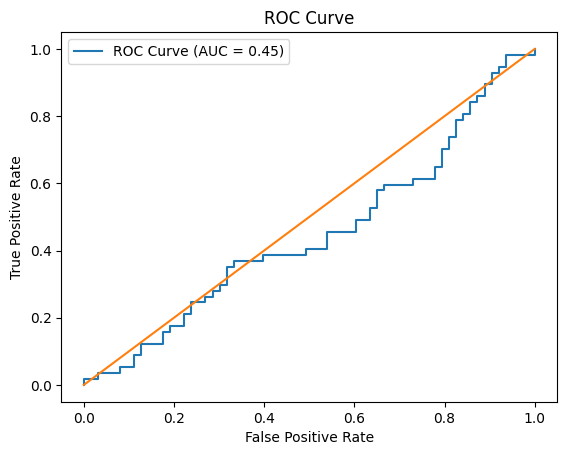

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The logistic regression model was trained using 80% of the data and tested on the remaining 20%. The categorical variables, like neighborhood and housing type, were turned into numbers, and missing values were filled in using the median.
The model had an accuracy of about 0.44 and an ROC–AUC of about 0.45. This means the model does not do a good job at telling the difference between expensive and less expensive homes.

## Part D – Model Understanding


**Accuracy vs AUC**

ROC–AUC is sometimes better than accuracy because accuracy only tells us how many predictions were right. ROC–AUC shows how well the model can tell the difference between the two groups. Accuracy can be misleading, but ROC–AUC gives a clearer picture.

**Inference vs Prediction**

For policy analysis, I would choose inference because it helps explain how different factors affect the outcome. For prediction tasks, I would choose prediction because the goal is to make the most accurate guesses.

## Part E – Explore the Dataset

1. Histogram of Price

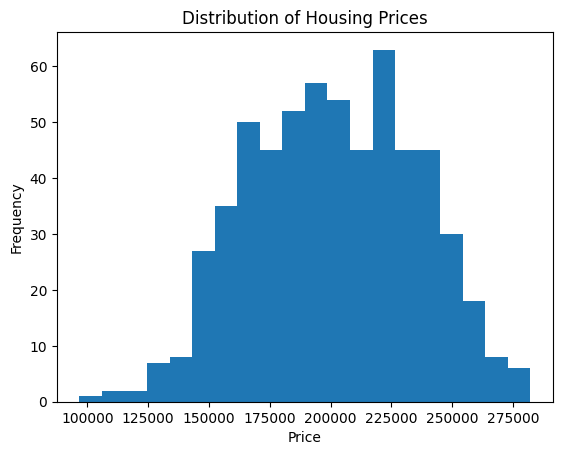

In [40]:
plt.figure()
plt.hist(df["price"], bins=20)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Housing Prices")
plt.show()

2. Scatter Plot (Size vs Price)

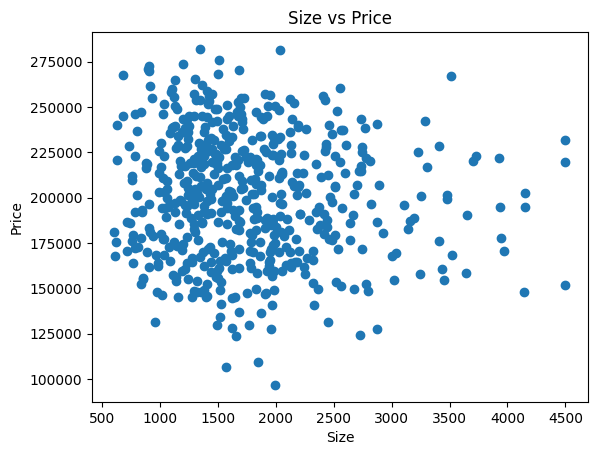

In [41]:
plt.figure()
plt.scatter(df["size"], df["price"])
plt.xlabel("Size")
plt.ylabel("Price")
plt.title("Size vs Price")
plt.show()

3. Boxplot (Price by Neighborhood)

<Figure size 640x480 with 0 Axes>

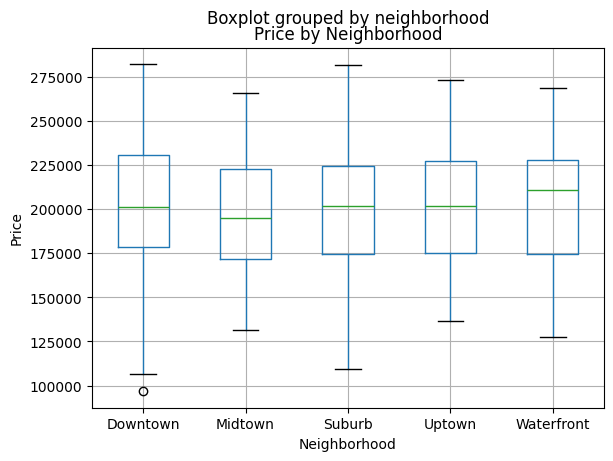

In [42]:
plt.figure()
df.boxplot(column="price", by="neighborhood")
plt.title("Price by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Price")
plt.show()

4. Bar Chart (Housing Type)

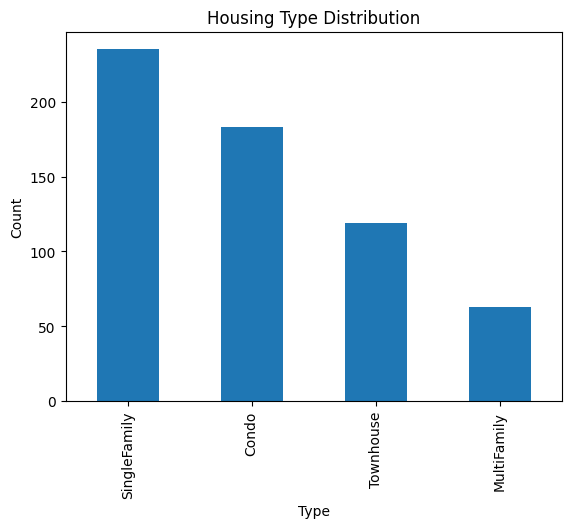

In [43]:
df["type"].value_counts().plot(kind="bar")
plt.title("Housing Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

One interesting pattern in the data is that there is no strong relationship between house size and price. The scatter plot shows that prices are spread out across different sizes, meaning that larger homes are not always more expensive. This suggests that other factors, such as neighborhood or housing type, may have a bigger impact on price than size alone.

The data exploration shows that price has a wide range, with some homes priced much higher than others. The scatter plot of size vs. price suggests that larger homes may sometimes have higher prices, but the relationship is not perfectly linear. The boxplot by neighborhood shows that some neighborhoods appear to have higher median prices than others, meaning location may be an important factor in predicting whether a home is considered high priced. This supports including neighborhood as a categorical predictor in the logistic regression model.